# 06 · Entrenar una U-Net en `cats-prueba` (prueba de que funciona)

Primer notebook de **Fase 2 (imágenes)**: entrenar la red de score convolucional `ScoreUNet` sobre
el dataset mínimo `data/cats-prueba` — **solo 2 imágenes** de 64×64. El objetivo **no** es generalizar
(imposible con 2 imágenes) sino **verificar que el pipeline de imágenes entrena de punta a punta**.

Con 2 imágenes esto es una **prueba de memorización (overfitting)**: si todo está bien conectado, la
red memoriza las 2 imágenes y lo confirmamos con **tres señales**:

1. **La pérdida DSM cae fuerte** (la red aprende el score de esas 2 imágenes).
2. **Denoising de un gato real**: ruideamos un gato hasta un `t` intermedio y lo reconstruimos con el
   proceso reverso → debería recuperar el gato (la señal más fuerte de "funciona").
3. **Generación desde ruido**: partir de $\mathcal N(0,I)$ e integrar el reverso. Con solo 2 imágenes
   el score lejos de los datos es poco fiable, así que esto es lo más frágil (ver la nota abajo).

### Qué se tuvo en cuenta

- **Overfitting es el objetivo**, no un problema: éxito = pérdida que baja + denoising que recupera.
- **`batch_size ≤ 2`**: `infinite_batches` corta con `ValueError` si pedís más imágenes que las que
  hay. Usamos `batch_size=2` (batch completo), `augment=False`, `seed` fijo → memorización limpia y
  reproducible.
- **32×32 + U-Net chica**: la U-Net por defecto tiene ~17M parámetros (lenta en CPU). Bajamos a
  `image_size=32` y una config chica (~1M parámetros) para que la prueba corra en ~1–2 min en CPU.
- **Normalización `[-1, 1]`**: `infinite_batches` entrega float32 en `[-1,1]` (la escala del prior
  gaussiano de la VP-SDE). Para mostrar, `denorm` vuelve a `[0,1]`.
- **SDE de imágenes**: `make_sde("vp", data_dim=(3,32,32))` — la forma de evento entra como **tupla**;
  `perturb`/`prior_sampling` operan sobre `(B,C,H,W)` y `dsm_loss` es agnóstico al rango (el peso
  `σ_t²` broadcastea a `(B,1,1,1)`).
- **Sampler para generar**: usamos **predictor–corrector (`pc`)**, cuyas correcciones de Langevin
  mantienen las muestras cerca de la variedad de datos; con este modelo overfit los samplers ODE
  puros (`pf_ode`/`heun`) y Euler divergen a valores enormes. Para el denoising, que arranca cerca del
  dato, alcanza `pf_ode`.

> **Entorno:** este notebook necesita **torchvision** (no solo torch), así que corré el kernel del
> entorno `uv` del proyecto (`.venv`), no un Python suelto. Es la diferencia con los notebooks 2D.

In [8]:
# --- Setup: bootstrap de sys.path + imports + helpers de imagen ---
import sys
import pathlib
import time

_here = pathlib.Path.cwd()
_root = None
for _cand in (_here, *_here.parents):
    if (_cand / "src" / "diffusion").is_dir():
        _root = _cand
        break
if _root is None:
    raise RuntimeError(f"No encontré src/diffusion subiendo desde {_here}")
_src = str((_root / "src").resolve())
if _src not in sys.path:
    sys.path.insert(0, _src)

import numpy as np
import torch
import matplotlib.pyplot as plt

from diffusion.data_generation import infinite_batches
from diffusion.models import make_model
from diffusion.sde import make_sde
from diffusion.training import TrainConfig, train, save_checkpoint
from diffusion.samplers import make_sampler, generate_from_checkpoint

SEED = 0
torch.manual_seed(SEED)
np.random.seed(SEED)
plt.rcParams.update({"figure.dpi": 110})


def denorm(t):
    """(B,3,H,W) en [-1,1] -> (B,H,W,3) numpy en [0,1] (clamp para muestras fuera de rango)."""
    x = (t.detach() * 0.5 + 0.5).clamp(0.0, 1.0)
    return x.permute(0, 2, 3, 1).cpu().numpy()


def show_row(imgs, titles=None, suptitle=None):
    arr = denorm(imgs) if torch.is_tensor(imgs) else imgs
    n = arr.shape[0]
    fig, axes = plt.subplots(1, n, figsize=(2.5 * n, 2.7))
    axes = np.atleast_1d(axes)
    for i, ax in enumerate(axes):
        ax.imshow(arr[i])
        ax.axis("off")
        if titles is not None:
            ax.set_title(titles[i], fontsize=9)
    if suptitle:
        fig.suptitle(suptitle)
    fig.tight_layout()
    plt.show()


print("paquete en:", _root)
print("torch:", torch.__version__)

paquete en: c:\Users\bravo\Facultad\calculo-estocastico\tp-final\diffusion-models
torch: 2.12.0+cpu


## El dataset: 2 gatos

`infinite_batches` descubre las imágenes bajo la carpeta, las lleva a `image_size×image_size` RGB en
`[-1,1]` y devuelve un iterador **infinito** de tensores `(B,3,H,W)`. Con `augment=False` y `seed`
fijo la secuencia es reproducible.

batch: (2, 3, 32, 32) torch.float32 rango (-0.851, 0.976)


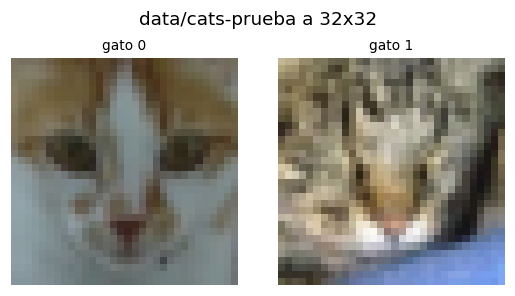

In [9]:
CATS = _root / "data" / "cats-prueba"
IMG = 32

data = infinite_batches(
    CATS, batch_size=2, image_size=IMG,
    augment=False, shuffle=False, num_workers=0, seed=SEED,
)
x0 = next(data)   # (2, 3, IMG, IMG) float32 en [-1, 1]

assert tuple(x0.shape) == (2, 3, IMG, IMG), x0.shape
assert x0.dtype == torch.float32
assert -1.01 <= float(x0.min()) and float(x0.max()) <= 1.01
print("batch:", tuple(x0.shape), x0.dtype, "rango",
      (round(float(x0.min()), 3), round(float(x0.max()), 3)))

show_row(x0, titles=["gato 0", "gato 1"], suptitle=f"data/cats-prueba a {IMG}x{IMG}")

## La red (U-Net chica) y el forward SDE

`ScoreUNet` es la red de score de Fase 2 (convolucional, GroupNorm, determinística). La construimos
vía `make_model("unet", ...)` con una config chica (~1M parámetros). El forward es una **VP-SDE** con
forma de evento `(3, 32, 32)`.

In [ ]:
UNET_KWARGS = dict(
    in_channels=3, image_size=IMG,
    base_channels=32, channel_mults=(1, 2, 2),   # IMG divisible por 2**(3-1)=4
    num_res_blocks=1, embed_dim=64, time_embed_dim=128,
    attn_resolutions=(), groups=8,               # groups divide {32, 64, 64}
    time_scale=1000.0,                           # escala del embedding de tiempo: resolución a t chico (convención DDPM/Song)
)
net = make_model("unet", **UNET_KWARGS)
sde = make_sde("vp", data_dim=(3, IMG, IMG))

n_params = sum(p.numel() for p in net.parameters())
print(f"ScoreUNet: {n_params:,} parámetros")
print(f"VP-SDE: data_shape={sde.data_shape}, T={sde.T}")

## Entrenar (memorizar las 2 imágenes)

Loop de *denoising score matching* por pasos. Con 2 imágenes y ~1M de parámetros la pérdida debería
**caer marcadamente** en unos cientos de pasos (memorización). En CPU, ~800 pasos ≈ 1–2 min.

[vp] paso 100/5000  pérdida(móvil)=0.213157
[vp] paso 200/5000  pérdida(móvil)=0.142232
[vp] paso 300/5000  pérdida(móvil)=0.100002
[vp] paso 400/5000  pérdida(móvil)=0.105126
[vp] paso 500/5000  pérdida(móvil)=0.045827
[vp] paso 600/5000  pérdida(móvil)=0.073281
[vp] paso 700/5000  pérdida(móvil)=0.052693
[vp] paso 800/5000  pérdida(móvil)=0.053332
[vp] paso 900/5000  pérdida(móvil)=0.047555
[vp] paso 1000/5000  pérdida(móvil)=0.049648
[vp] paso 1100/5000  pérdida(móvil)=0.050648
[vp] paso 1200/5000  pérdida(móvil)=0.043437
[vp] paso 1300/5000  pérdida(móvil)=0.038034
[vp] paso 1400/5000  pérdida(móvil)=0.047454
[vp] paso 1500/5000  pérdida(móvil)=0.036707
[vp] paso 1600/5000  pérdida(móvil)=0.016605
[vp] paso 1700/5000  pérdida(móvil)=0.021800
[vp] paso 1800/5000  pérdida(móvil)=0.047465
[vp] paso 1900/5000  pérdida(móvil)=0.036353
[vp] paso 2000/5000  pérdida(móvil)=0.033258
[vp] paso 2100/5000  pérdida(móvil)=0.024112
[vp] paso 2200/5000  pérdida(móvil)=0.027471
[vp] paso 2300/5000

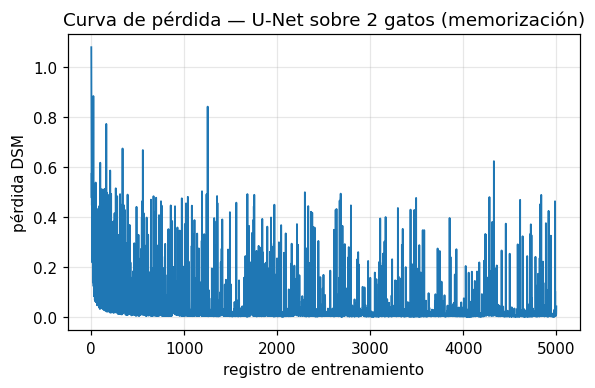

In [11]:
cfg = TrainConfig(num_steps=5000, lr=1e-3, t_eps=1e-4, device="cpu", log_every=100, seed=SEED)

t0 = time.time()
result = train(sde, net, data, cfg)
print(f"entrenamiento: {time.time() - t0:.1f}s  "
      f"pérdida {result.history[0]:.4f} -> {result.history[-1]:.4f}  "
      f"(mín {min(result.history):.4f})")

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(result.history, lw=1.2)
ax.set_xlabel("registro de entrenamiento")
ax.set_ylabel("pérdida DSM")
ax.set_title("Curva de pérdida — U-Net sobre 2 gatos (memorización)")
ax.grid(alpha=0.3)
plt.show()

Guardamos un checkpoint **reconstruible**: además del `state_dict`, la receta `model_spec`
(`{name, kwargs}`) permite rearmar la red con `make_model` sin conocer la arquitectura de antemano
(igual que hizo el notebook `05`).

In [12]:
CKPT = _root / "models" / "phase_2" / "cats_prueba_vp.pt"
save_checkpoint(result, CKPT, model_spec={"name": "unet", "kwargs": UNET_KWARGS})
print("checkpoint guardado en:", CKPT.relative_to(_root), "| existe:", CKPT.exists())

checkpoint guardado en: models\phase_2\cats_prueba_vp.pt | existe: True


## Prueba 2 — Denoising de un gato real (la señal fuerte)

Ruideamos un gato real hasta un tiempo intermedio $t_0$ con `sde.perturb`, y después integramos el
**reverso** desde $t_0$ hasta $t_\epsilon$ para reconstruirlo. Si la red memorizó bien, el gato
reaparece.

El driver estándar del sampler integra siempre de $T$ a $t_\epsilon$; para arrancar en un $t_0$
intermedio reusamos su método público `step()` sobre una grilla corta $t_0\to t_\epsilon$ (la misma
discretización que usa el driver, solo con otro punto de partida).

MSE contra el original: ruidoso(t=0.5)=0.9802  ->  reconstruido=0.0072


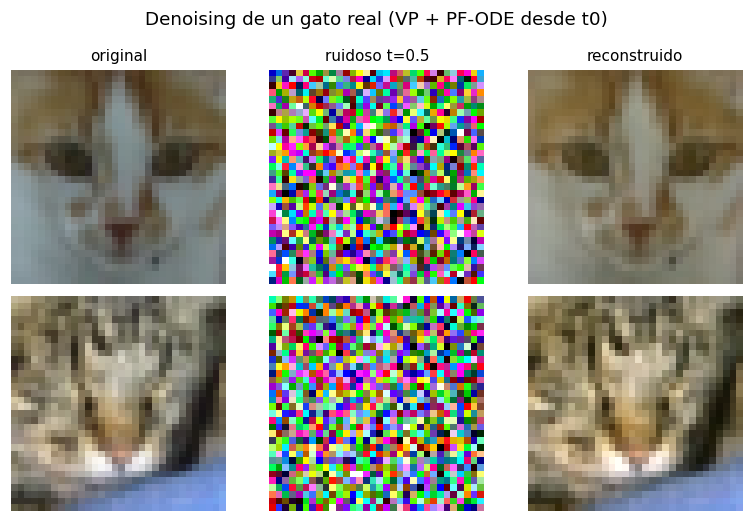

In [19]:
net.eval()
sampler = make_sampler("pf_ode", sde, net, n_steps=200, t_eps=cfg.t_eps)


def denoise_from(sampler, x_t, t0, n_steps):
    """Integra el reverso desde t0 hasta t_eps reusando sampler.step (grilla propia)."""
    grid = torch.linspace(t0, sampler.t_eps, n_steps + 1)
    x = x_t.clone()
    for i in range(n_steps):
        dt = (grid[i + 1] - grid[i]).item()          # negativo: tiempo decreciente
        x = sampler.step(x, grid[i].expand(x.shape[0], 1), dt, generator=None)
    return x


T0 = 0.5
g = torch.Generator().manual_seed(SEED)
x_t, _ = sde.perturb(x0, torch.full((x0.shape[0],), T0), generator=g)
with torch.no_grad():
    x_rec = denoise_from(sampler, x_t, T0, n_steps=120)

mse0 = float(((x_t - x0) ** 2).mean())
mse1 = float(((x_rec - x0) ** 2).mean())
print(f"MSE contra el original: ruidoso(t={T0})={mse0:.4f}  ->  reconstruido={mse1:.4f}")

# Grilla original | ruidoso(t0) | reconstruido, una fila por gato.
orig, noisy, rec = denorm(x0), denorm(x_t), denorm(x_rec)
cols = [("original", orig), (f"ruidoso t={T0}", noisy), ("reconstruido", rec)]
fig, axes = plt.subplots(x0.shape[0], 3, figsize=(3 * 2.4, x0.shape[0] * 2.4))
for r in range(x0.shape[0]):
    for c, (ttl, arr) in enumerate(cols):
        ax = axes[r, c]
        ax.imshow(arr[r]); ax.axis("off")
        if r == 0:
            ax.set_title(ttl, fontsize=10)
fig.suptitle("Denoising de un gato real (VP + PF-ODE desde t0)")
fig.tight_layout()
plt.show()

## Prueba 3 — Generación desde ruido

Partimos de $x_T\sim\mathcal N(0,I)$ e integramos el reverso completo con **predictor–corrector**
(`pc`): sus pasos de Langevin corrigen hacia zonas de más densidad y evitan la divergencia que sí
sufren los samplers ODE puros con un modelo tan overfit.

**Expectativa realista:** con solo 2 imágenes el score lejos de los datos es pobre, así que las
muestras salen toscas (no gatos nítidos). Que el pipeline **corra de punta a punta y devuelva imágenes
`(N,3,32,32)`** ya valida la Fase 2; el denoising de arriba es la prueba visual fuerte.

generado: (4, 3, 32, 32) | rango (-0.95, 3.19) | finito True


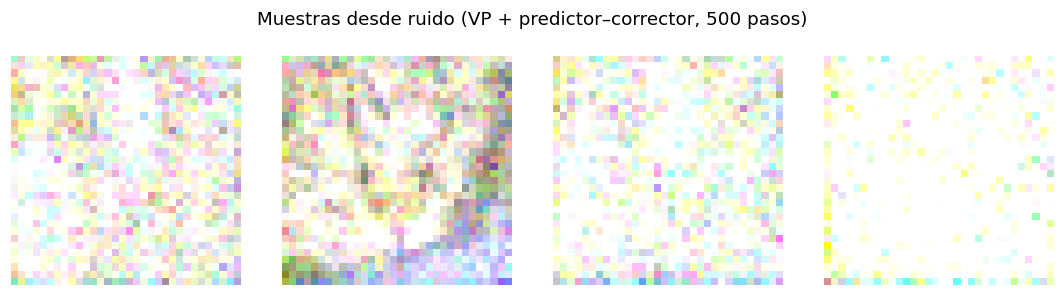

In [23]:
gen = generate_from_checkpoint(CKPT, "pc", n_samples=4, n_steps=500, seed=SEED)
print("generado:", tuple(gen.shape),
      "| rango", (round(float(gen.min()), 2), round(float(gen.max()), 2)),
      "| finito", bool(torch.isfinite(gen).all()))
show_row(gen, suptitle="Muestras desde ruido (VP + predictor–corrector, 500 pasos)")

## Cierre

- El pipeline de **Fase 2 entrena de punta a punta**: `infinite_batches` (imágenes) → `make_sde(...,
  data_dim=(3,32,32))` → `ScoreUNet` → `dsm_loss`/`train` → checkpoint reconstruible.
- **La pérdida cae fuerte** y el **denoising recupera los gatos**: la red memorizó las 2 imágenes.
- La **generación desde ruido** corre y devuelve imágenes válidas, aunque toscas — lo esperable con 2
  imágenes.

**Para escalar** (ya no como prueba): subir a `image_size=64`, apuntar a un dataset real
(`data/cats-v1`, 9304 imágenes), agrandar la U-Net (más `base_channels`/`channel_mults`, reactivar
`attn_resolutions`) y entrenar muchos más pasos con `augment=True`.